# Day 1 - Basic Model Traing

In [38]:
import os
from dotenv import load_dotenv
from huggingface_hub import login
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from datasets import Dataset, DatasetDict, concatenate_datasets
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from litellm import completion
from tqdm.notebook import tqdm
from pricer.evaluator import evaluate

In [39]:
load_dotenv()

True

In [40]:
hf_token = os.getenv("HF_TOKEN")
login(hf_token, add_to_git_credential=True)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [41]:
ADMR = "ADMR.JK"
PANI = "PANI.JK"
PTRO = "PTRO.JK"
BUMI = "BUMI.JK"
HORIZON = 30

In [42]:
df = yf.Tickers(f"{ADMR} {PANI} {PTRO} {BUMI}").history(period="max")

[*********************100%***********************]  4 of 4 completed


In [43]:
df

Price        Close                             Dividends                  \
Ticker     ADMR.JK     BUMI.JK PANI.JK PTRO.JK   ADMR.JK BUMI.JK PANI.JK   
Date                                                                       
2001-06-07     NaN   42.833710     NaN     NaN       NaN     0.0     NaN   
2001-06-08     NaN   42.833710     NaN     NaN       NaN     0.0     NaN   
2001-06-11     NaN   47.117085     NaN     NaN       NaN     0.0     NaN   
2001-06-12     NaN   47.117085     NaN     NaN       NaN     0.0     NaN   
2001-06-13     NaN   42.833710     NaN     NaN       NaN     0.0     NaN   
...            ...         ...     ...     ...       ...     ...     ...   
2026-04-20  1905.0  242.000000  8750.0  6075.0       0.0     0.0     0.0   
2026-04-21  1865.0  240.000000  9425.0  6300.0       0.0     0.0     0.0   
2026-04-22  1855.0  240.000000  9225.0  6250.0       0.0     0.0     0.0   
2026-04-23  1845.0  230.000000  9050.0  6175.0       0.0     0.0     0.0   
2026-04-24  1880.0  216.000000  8500.0  5600.0       0.0     0.0     0.0   

Price                 High              ...    Open         Stock Splits  \
Ticker     PTRO.JK ADMR.JK     BUMI.JK  ... PANI.JK PTRO.JK      ADMR.JK   
Date                                    ...                                
2001-06-07     NaN     NaN   42.833710  ...     NaN     NaN          NaN   
2001-06-08     NaN     NaN   42.833710  ...     NaN     NaN          NaN   
2001-06-11     NaN     NaN   51.400456  ...     NaN     NaN          NaN   
2001-06-12     NaN     NaN   51.400456  ...     NaN     NaN          NaN   
2001-06-13     NaN     NaN   47.117081  ...     NaN     NaN          NaN   
...            ...     ...         ...  ...     ...     ...          ...   
2026-04-20     0.0  1940.0  250.000000  ...  9000.0  6250.0          0.0   
2026-04-21     0.0  1900.0  244.000000  ...  8775.0  6025.0          0.0   
2026-04-22     0.0  1885.0  246.000000  ...  9475.0  6350.0          0.0   
2026-04-23     0.0  1880.0  242.000000  ...  9225.0  6275.0          0.0   
2026-04-24     0.0  1925.0  236.000000  ...  9050.0  6225.0          0.0   

Price                                   Volume                          \
Ticker     BUMI.JK PANI.JK PTRO.JK     ADMR.JK     BUMI.JK     PANI.JK   
Date                                                                     
2001-06-07     0.0     NaN     NaN         NaN     3869000         NaN   
2001-06-08     0.0     NaN     NaN         NaN     6038500         NaN   
2001-06-11     0.0     NaN     NaN         NaN     8006000         NaN   
2001-06-12     0.0     NaN     NaN         NaN      537000         NaN   
2001-06-13     0.0     NaN     NaN         NaN     1341500         NaN   
...            ...     ...     ...         ...         ...         ...   
2026-04-20     0.0     0.0     0.0  19839200.0  2320011600   6120200.0   
2026-04-21     0.0     0.0     0.0  36164700.0  2190621300  11543800.0   
2026-04-22     0.0     0.0     0.0  25625300.0  1883526900   6620900.0   
2026-04-23     0.0     0.0     0.0  25486300.0  3490960700   4322000.0   
2026-04-24     0.0     0.0     0.0  48337900.0  4442692000   8074300.0   

Price                    
Ticker          PTRO.JK  
Date                     
2001-06-07          NaN  
2001-06-08          NaN  
2001-06-11          NaN  
2001-06-12          NaN  
2001-06-13          NaN  
...                 ...  
2026-04-20   50766900.0  
2026-04-21   98619000.0  
2026-04-22   65449000.0  
2026-04-23   62695100.0  
2026-04-24  105694400.0  

[6177 rows x 28 columns]

In [44]:
close_df = df["Close"]

future_price = close_df.shift(-HORIZON)
target_return = (future_price - close_df) / close_df
ma_200 = close_df.rolling(window=200).mean()
ma_150 = close_df.rolling(window=150).mean()
ma_50  = close_df.rolling(window=50).mean()

In [45]:
df = pd.concat([
    df,
    ma_200.rename(columns=lambda x: ("MA 200", x)),
    ma_150.rename(columns=lambda x: ("MA 150", x)),
    ma_50.rename(columns=lambda x: ("MA 50", x)),
    future_price.rename(columns=lambda x: ("Future Price", x)),
    target_return.rename(columns=lambda x: ("Target Return", x)),
], axis=1)

In [46]:
df.columns.names = ["Price", "Ticker"]

In [47]:
df.columns

MultiIndex([(        'Close', 'ADMR.JK'),
            (        'Close', 'BUMI.JK'),
            (        'Close', 'PANI.JK'),
            (        'Close', 'PTRO.JK'),
            (    'Dividends', 'ADMR.JK'),
            (    'Dividends', 'BUMI.JK'),
            (    'Dividends', 'PANI.JK'),
            (    'Dividends', 'PTRO.JK'),
            (         'High', 'ADMR.JK'),
            (         'High', 'BUMI.JK'),
            (         'High', 'PANI.JK'),
            (         'High', 'PTRO.JK'),
            (          'Low', 'ADMR.JK'),
            (          'Low', 'BUMI.JK'),
            (          'Low', 'PANI.JK'),
            (          'Low', 'PTRO.JK'),
            (         'Open', 'ADMR.JK'),
            (         'Open', 'BUMI.JK'),
            (         'Open', 'PANI.JK'),
            (         'Open', 'PTRO.JK'),
            ( 'Stock Splits', 'ADMR.JK'),
            ( 'Stock Splits', 'BUMI.JK'),
            ( 'Stock Splits', 'PANI.JK'),
            ( 'Stock Splits', 'PTR

In [48]:
df_long = df.stack(level=1).reset_index()

In [49]:
df_long.dropna(inplace=True)

In [50]:
print(f"The dataset contains {len(df_long)} rows after dropping missing values.")

The dataset contains 14084 rows after dropping missing values.


In [51]:
print(f"Sample price at t: {df_long['Close'].iloc[0]}")
print(f"Sample return at t: {df_long['Target Return'].iloc[0]}")

Sample price at t: 29.98360252380371
Sample return at t: 0.14285717920746147


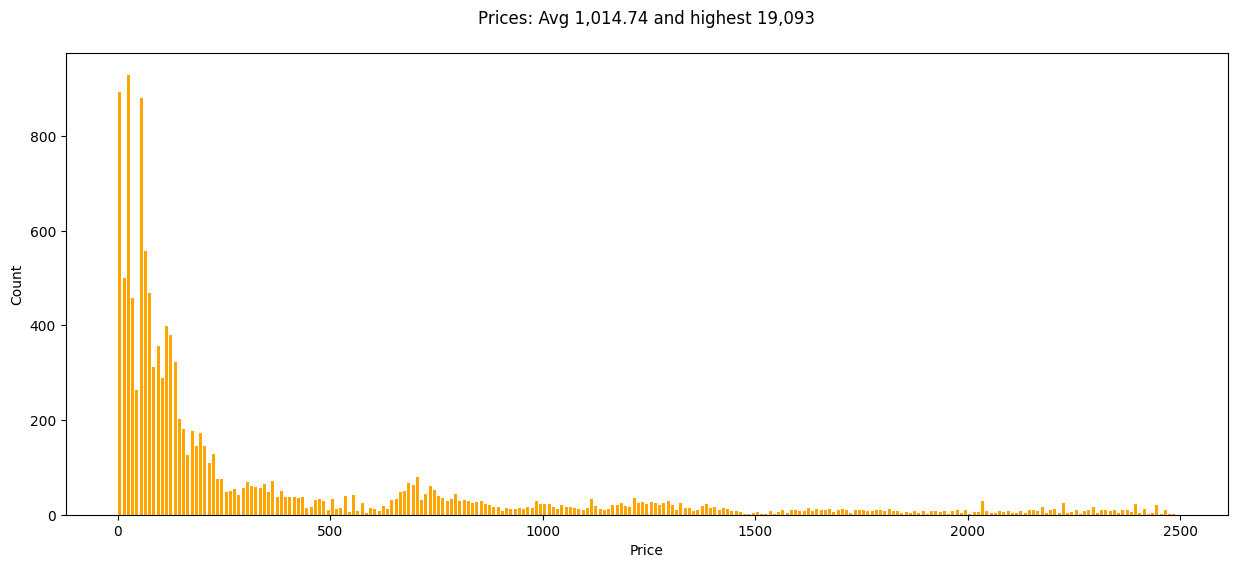

In [52]:
import matplotlib.pyplot as plt

close_values = df_long["Close"].values

plt.figure(figsize=(15, 6))
plt.title(
    f"Prices: Avg {close_values.mean():,.2f} "
    f"and highest {close_values.max():,.0f}\n"
)
plt.xlabel('Price')
plt.ylabel('Count')

plt.hist(close_values, rwidth=0.7, color="orange", bins=range(0, 2500, 10))

plt.show()

In [53]:
train = df_long.iloc[:int(0.8*len(df_long))]
val = df_long.iloc[int(0.8*len(df_long)):int(0.9*len(df_long))]
test = df_long.iloc[int(0.9*len(df_long)):]

In [55]:
ds = DatasetDict(
    {
        "train": Dataset.from_pandas(train),
        "val": Dataset.from_pandas(val),
        "test": Dataset.from_pandas(test),
    }
)

In [56]:
print(f"Train size: {len(train)}, Validation size: {len(val)}, Test size: {len(test)}")

Train size: 11267, Validation size: 1408, Test size: 1409


In [ ]:
def rolling_150_pricer(item):
    return item["MA 150"]

In [59]:
rolling_evaluator = evaluate(rolling_150_pricer, ds["test"])

  0%|          | 0/200 [00:00<?, ?it/s]

987 40 55 9519 971 97 53 9311 906 93 53 9477 951 50 53 9342 933 41 52 10503 1081 31 48 11718 1049 7 48 11482 1009 37 51 11697 965 5 47 11157 936 4 42 11011 1010 37 39 10964 1052 10 61 9845 1139 18 85 10599 1093 8 75 9881 1134 26 72 8741 1061 45 59 8282 1042 97 63 7970 1029 59 60 8381 1055 45 56 8069 1104 41 52 7905 1058 64 52 7862 1055 88 55 7819 1056 83 49 8873 1017 87 43 8598 1040 125 54 9115 1114 100 45 8905 1322 100 44 8636 1299 76 45 8541 1438 32 45 8500 1492 37 44 10239 1574 8 47 11174 1521 32 53 10710 1633 51 50 12144 1720 80 49 11881 1692 109 47 11484 1613 147 43 8730 1627 181 38 8650 1571 205 35 8668 1705 214 25 8290 1679 196 17 8563 1770 225 18 8761 1825 197 18 8568 1805 211 17 8295 1821 150 19 8225 1743 183 23 9489 1716 216 24 9254 1842 240 18 8672 1752 264 19 9187 1652 292 13 9604 1842 311 6 10047 

In [60]:
def get_features(item):
    return {
        "Close": item["Close"],
        "Volume": item["Volume"],
        "Dividends": item["Dividends"],
        "MA 200": item["MA 200"],
        "MA 150": item["MA 150"],
        "MA 50": item["MA 50"],
    }

In [62]:
np.random.seed(42)

feature_columns = ["Close", "Volume", "Dividends", "MA 200", "MA 150", "MA 50"]

X_train = train[feature_columns]
y_train = train["Future Price"]
X_test = test[feature_columns]
y_test = test["Future Price"]

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
def linear_regression_pricer(item):
    features = get_features(item)
    features_df = pd.DataFrame([features])
    return lr_model.predict(features_df)[0]

In [64]:
evaluate(linear_regression_pricer, ds["test"])

  0%|          | 0/200 [00:00<?, ?it/s]

274 164 18 5043 283 210 14 4671 224 167 6 4992 281 134 8 4638 310 85 8 5066 458 87 10 6869 587 84 20 6503 461 123 13 7047 278 46 15 5576 202 28 22 4390 318 88 24 4168 419 71 3 3649 447 104 5 4199 367 158 11 3877 442 176 3 2898 396 168 17 3339 451 243 18 2318 462 112 15 2657 416 137 11 2501 455 105 18 2351 451 107 21 1522 420 121 26 1555 390 139 30 2516 365 150 32 1550 406 156 32 899 468 150 32 241 705 184 31 1473 686 149 33 1745 508 96 43 872 653 74 40 1975 688 29 31 2093 657 120 22 1905 848 134 24 3184 888 113 25 3109 885 130 26 1414 641 158 26 2686 698 163 30 2441 693 220 36 2613 882 180 43 2322 893 172 44 1841 904 238 39 1550 917 155 67 423 804 202 99 1531 878 129 81 740 759 124 73 1862 823 135 59 2189 976 99 66 1991 908 166 61 2061 784 212 62 2866 924 237 65 3524 

In [65]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [ ]:
def random_forest(item):
    features = get_features(item)
    features_df = pd.DataFrame([features])
    return rf_model.predict(features_df)[0]

In [67]:
evaluate(random_forest, ds["test"])

  0%|          | 0/200 [00:00<?, ?it/s]

541 151 18 9351 541 90 15 9167 628 173 2 9404 427 28 7 9372 529 312 5 10890 590 525 7 12153 750 167 14 11954 536 15 5 12209 307 323 11 11661 216 465 14 11563 347 621 17 11552 515 502 0 10636 594 474 17 11619 478 658 2 11514 602 370 13 11414 519 29 2 11201 540 298 6 10925 479 445 4 11382 420 312 3 11221 377 39 3 10766 430 52 2 10869 413 29 0 10869 92 15 5 11968 172 40 7 11743 237 297 0 12318 143 72 8 12168 533 354 5 11968 497 52 2 11943 3 51 17 11968 98 42 5 13768 167 81 13 14767 343 405 5 14367 256 17 6 15867 547 240 6 15667 813 156 4 15342 176 30 3 12668 203 83 5 12668 196 149 6 12768 581 132 22 12468 307 86 31 12818 370 102 31 13093 494 128 40 12968 472 102 65 12768 485 45 62 12768 714 132 45 14092 680 173 22 13918 718 249 24 13393 999 242 11 13968 557 243 15 14442 848 272 24 14942 

In [69]:
def messages_for(item):
    message = f"You are a financial model. Given the input data, predict the stock price at time t+30. Return ONLY one decimal number with 2 digits after decimal; No explanation, no currency symbol. no extra text.\n\nClose: {item['Close']}\nVolume: {item['Volume']}\nDividends: {item['Dividends']}\nMA 200: {item['MA 200']}\nMA 150: {item['MA 150']}\nMA 50: {item['MA 50']}\n\nAnswer:"
    return [{"role": "user", "content": message}]

In [72]:
messages_for(ds["test"][0])

[{'role': 'user',
  'content': 'You are a financial model. Given the input data, predict the stock price at time t+30. Return ONLY one decimal number with 2 digits after decimal; No explanation, no currency symbol. no extra text.\n\nClose: 1349.99951171875\nVolume: 50321000.0\nDividends: 0.0\nMA 200: 656.7252352905274\nMA 150: 712.9223980712891\nMA 50: 941.3496594238281\n\nAnswer:'}]

In [73]:
def gpt_4__1_nano(item):
    response = completion(model="openai/gpt-4.1-nano", messages=messages_for(item))
    return response.choices[0].message.content

In [74]:
gpt_4__1_nano(ds["test"][0])

'1519.25'

In [75]:
print(f"Actual price at t+30: {ds['test'][0]['Future Price']}")

Actual price at t+30: 1699.9993896484375


In [76]:
evaluate(gpt_4__1_nano, ds["test"])

  0%|          | 0/200 [00:00<?, ?it/s]

130 79 39 4662 255 143 34 4359 225 129 26 4962 140 94 24 3907 362 9 17 4910 270 28 13 2196 563 52 4 5800 503 84 13 6932 256 13 12 4921 222 108 2 4266 204 151 2 4448 351 119 23 3973 446 188 7 4714 393 224 18 2168 461 243 21 3112 403 243 12 3375 476 311 8 2722 339 176 2 3014 446 220 17 2283 665 151 10 1445 415 163 6 1670 405 186 2 349 396 192 2 2711 372 207 7 1690 430 210 2 866 492 201 6 806 692 237 15 730 696 207 12 1924 548 167 11 15363 681 125 12 1854 661 69 6 2209 706 164 0 128 1162 179 3 2984 900 155 18 3769 1659 183 12 9678 590 210 15 2689 767 193 13 13361 687 254 60 1830 917 216 16 9453 882 209 19 3882 872 292 16 1696 938 144 48 124 831 243 65 2949 892 161 53 2759 795 141 49 96 806 201 29 1896 991 80 55 1060 887 249 52 2404 1136 244 37 2279 942 262 42 3126 